In [ ]:
"""
Teaser-Figur exakt nach LaTeX nachbauen

Anpassen:
 - root: Pfad, in dem der Ordner "figures/teaser" liegt (oder setze direkt auf "figures/teaser")
 - poppler_path: falls pdftoppm nicht im PATH ist (z.B. "/usr/bin")
 - Ausgabe: teaser_exact.png, teaser_exact.pdf

Benötigt:
 pip install pillow pdf2image
 apt install poppler-utils   # oder entsprechender installer für dein OS
"""

from PIL import Image, ImageDraw, ImageFont
from pdf2image import convert_from_path
import os

# ----------------- Einstellungen -----------------
root = "/home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing"   # <-- anpassen
base = os.path.join(root, "figures", "teaser")
out_png = "teaser_exact.png"
out_pdf = "teaser_exact.pdf"

# Layout-Proportionen (entsprechen LaTeX: orig=0.3, each slice=0.1 -> 3 slices = 0.3)
col_group_width = 600   # Breite einer Spalte (Orig / Grayscale-group / Color-opponency-group / Single-color-group)
slice_width = col_group_width // 3  # 200 wenn col_group_width=600
target_h = 360          # Zielhöhe für Bilder und Slices
mask_h = target_h       # Höhe der Masken

left_label_w = 56
top_header_h = 48
col_gap = 12
row_gap = 14
bg = (255,255,255)

# Fonts
try:
    # passe ggf. font_path an oder setze None für default
    font_path = "/home/lstracke/Data/times.ttf"
    font_header = ImageFont.truetype(font_path, 25)
    font_label  = ImageFont.truetype(font_path, 25)
    font_small  = ImageFont.truetype(font_path, 12)
except Exception:
    font_header = ImageFont.load_default()
    font_label  = ImageFont.load_default()
    font_small  = ImageFont.load_default()

# ----------------- LaTeX-Dateinamen genau wie im Beispiel -----------------
# Die Pfade werden relativ zu base aufgebaut, so wie in deinem LaTeX
def p(*parts):
    return os.path.join(base, *parts)

file_map = {
    # Cityscapes
    ("Cityscapes", "Original Image"): [ p("image_beforeRGB.pdf") ],
    ("Cityscapes", "Grayscale"): [
        p("image_beforeRGB-1_-1gray_sig-r.pdf"),
        p("image_beforeRGB-1_-2gray_sig-g.pdf"),
        p("image_beforeRGB-1_-3gray_sig-b.pdf"),
    ],
    ("Cityscapes", "Color-opponency"): [
        p("image_beforeRGB-1_-1co_sig-r.pdf"),
        p("image_beforeRGB-1_-2co_sig-g.pdf"),
        p("image_beforeRGB-1_-3co_sig-b.pdf"),
    ],
    ("Cityscapes", "Single-color"): [
        p("image_beforeRGB-1_-1sc_sig-r.pdf"),
        p("image_beforeRGB-1_-2sc_sig-g.pdf"),
        p("image_beforeRGB-1_-3sc_sig-b.pdf"),
    ],
    ("Cityscapes", "Masks"): [
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_baseline_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_bw_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_co_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_sc_mask.pdf"),
    ],

    # Dark Zurich
    ("Dark Zurich", "Original Image"): [ p("image_before_night_dark_zurichRGB.pdf") ],
    ("Dark Zurich", "Grayscale"): [
        p("image_before_dark_zurich_RGB-1_-1gray_sig-r.pdf"),
        p("image_before_dark_zurich_RGB-1_-2gray_sig-g.pdf"),
        p("image_before_dark_zurich_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("Dark Zurich", "Color-opponency"): [
        p("image_before_dark_zurich_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-3co_sig-b.pdf"),
    ],
    ("Dark Zurich", "Single-color"): [
        p("sliced_processed","image_before_dark_zurich_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("Dark Zurich", "Masks"): [
        p("segmentation_masks_dark_zurich","GOPR0356_frame_000324_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_dark_zurich","GOPR0356_frame_000324_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_dark_zurich","GOPR0356_frame_000324_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_dark_zurich","GOPR0356_frame_000324_rgb_anon_sc_mask.pdf"),
    ],

    # ACDC Night
    ("ACDC Night", "Original Image"): [ p("image_before_acdc_nightRGB.pdf") ],
    ("ACDC Night", "Grayscale"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Night", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Night", "Single-color"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Night", "Masks"): [
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_sc_mask.pdf"),
    ],

    # ACDC Snow
    ("ACDC Snow", "Original Image"): [ p("image_before_acdc_snowRGB.pdf") ],
    ("ACDC Snow", "Grayscale"): [
        p("sliced_processed","image_before_acdc_snow_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Snow", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_snow_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Snow", "Single-color"): [
        p("sliced_processed","image_before_acdc_snow_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Snow", "Masks"): [
        p("segmentation_masks_acdc_snow","GOPR0122_frame_000018_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_snow","GOPR0122_frame_000018_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_snow","GOPR0122_frame_000018_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_snow","GOPR0122_frame_000018_rgb_anon_sc_mask.pdf"),
    ],

    # ACDC Fog
    ("ACDC Fog", "Original Image"): [ p("image_before_acdc_fogRGB.pdf") ],
    ("ACDC Fog", "Grayscale"): [
        p("sliced_processed","image_before_acdc_fog_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Fog", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_fog_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Fog", "Single-color"): [
        p("sliced_processed","image_before_acdc_fog_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Fog", "Masks"): [
        p("segmentation_masks_acdc_fog","GOPR0476_frame_000769_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_fog","GOPR0476_frame_000769_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_fog","GOPR0476_frame_000769_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_fog","GOPR0476_frame_000769_rgb_anon_sc_mask.pdf"),
    ],

    # ACDC Rain
    ("ACDC Rain", "Original Image"): [ p("image_before_acdc_rainRGB.pdf") ],
    ("ACDC Rain", "Grayscale"): [
        p("sliced_processed","image_before_acdc_rain_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Rain", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_rain_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Rain", "Single-color"): [
        p("sliced_processed","image_before_acdc_rain_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Rain", "Masks"): [
        p("segmentation_masks_acdc_rain","GOPR0400_frame_000087_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_rain","GOPR0400_frame_000087_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_rain","GOPR0400_frame_000087_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_rain","GOPR0400_frame_000087_rgb_anon_sc_mask.pdf"),
    ],
}

# ----------------- Helper-Funktionen -----------------
def load_any(path, dpi=150):
    """Lädt PDF (erste Seite) oder Bild, oder None wenn nicht existiert."""
    if not os.path.exists(path):
        return None
    try:
        if path.lower().endswith(".pdf"):
            pages = convert_from_path(path, dpi=dpi, poppler_path=poppler_path) if poppler_path else convert_from_path(path, dpi=dpi)
            im = pages[0].convert("RGB")
        else:
            im = Image.open(path).convert("RGB")
        return im
    except Exception as e:
        print(f"[WARN] konnte {path} nicht laden: {e}")
        return None

def center_text(draw, text, box, font, fill=(0,0,0)):
    bbox = draw.textbbox((0,0), text, font=font)
    tw = bbox[2]-bbox[0]; th = bbox[3]-bbox[1]
    x = box[0] + (box[2]-box[0]-tw)/2
    y = box[1] + (box[3]-box[1]-th)/2
    draw.text((x,y), text, font=font, fill=fill)

def make_placeholder(w,h,text="",font=font_small):
    im = Image.new("RGB",(w,h),(240,240,240))
    d = ImageDraw.Draw(im)
    center_text(d, text if text else "(missing)", (0,0,w,h), font)
    return im

def concat_horiz(images, bg=bg):
    if not images:
        return None
    total_w = sum(im.width for im in images)
    h = max(im.height for im in images)
    out = Image.new("RGB",(total_w,h),bg)
    x=0
    for im in images:
        out.paste(im,(x,(h-im.height)//2))
        x += im.width
    return out

# ----------------- Erzeuge Zellen (genau wie LaTeX) -----------------
columns = ["Original Image","Grayscale","Color-opponency","Single-color"]
rows = ["Cityscapes","Dark Zurich","ACDC Night","ACDC Snow","ACDC Fog","ACDC Rain"]

# Preload and resize each cell to the exact widths:
cells = {}   # cells[(row,col,"image" or "mask")] -> PIL.Image

for row in rows:
    # Original Image (one wide image -> resize to col_group_width x target_h)
    orig_files = file_map.get((row,"Original Image"), [])
    if orig_files:
        im = load_any(orig_files[0])
        if im is None:
            im = make_placeholder(col_group_width, target_h, text=os.path.basename(orig_files[0]))
        else:
            im = im.resize((col_group_width, target_h), Image.LANCZOS)
    else:
        im = make_placeholder(col_group_width, target_h, text="(no orig)")
    cells[(row,"Original Image")] = im

    # For each of the three grouped columns, load three slice images and concat horizontally.
    for group,colname in enumerate(["Grayscale","Color-opponency","Single-color"]):
        files = file_map.get((row, colname), [])
        parts = []
        # We expect exactly 3 slice files per group; if fewer, fill placeholders.
        for i in range(3):
            if i < len(files):
                f = files[i]
                p_img = load_any(f)
                if p_img is None:
                    p_img = make_placeholder(slice_width, target_h, text=os.path.basename(f))
                else:
                    p_img = p_img.resize((slice_width, target_h), Image.LANCZOS)
            else:
                p_img = make_placeholder(slice_width, target_h, text="(missing)")
            parts.append(p_img)
        grouped = concat_horiz(parts)
        # grouped should be width == col_group_width
        cells[(row,colname)] = grouped

    # Masks: 4 mask images side-by-side? In LaTeX each mask is in its own column (4 masks),
    # but our table has 4 columns: Original Image + 3 groups. In LaTeX they placed 4 mask files:
    # one under orig, one under grayscale, one under color-opponency, one under single-color.
    mask_files = file_map.get((row,"Masks"), [])
    # If there are fewer than 4, create placeholders accordingly.
    for j in range(4):
        if j < len(mask_files):
            f = mask_files[j]
            m = load_any(f)
            if m is None:
                m = make_placeholder(col_group_width, mask_h, text=os.path.basename(f))
            else:
                m = m.resize((col_group_width, mask_h), Image.LANCZOS)
        else:
            m = make_placeholder(col_group_width, mask_h, text="(no mask)")
        # assign masks to columns in order: Orig, Grayscale, Color-opponency, Single-color
        colkey = ["Original Image","Grayscale","Color-opponency","Single-color"][j]
        cells[(row, f"mask_{colkey}")] = m

# ----------------- Gesamt-Canvas Größe -----------------
W = left_label_w + 4*col_group_width + 3*col_gap
H = top_header_h + sum((target_h + mask_h + row_gap) for _ in rows)  # each dataset uses two stacked rows (images + masks)
canvas = Image.new("RGB",(W,H),bg)
draw = ImageDraw.Draw(canvas)

# ----------------- Header -----------------
x = left_label_w
for col in columns:
    # column label centered above column (LaTeX had header row)
    tw = draw.textbbox((0,0), col, font=font_header)[2]
    draw.text((x + (col_group_width - tw)/2, 6), col, font=font_header, fill=(0,0,0))
    x += col_group_width + col_gap

# ----------------- Fill rows -----------------
y = top_header_h
for row in rows:
    # Left vertical label rotated 90deg (like \rotatebox{90}{...})
    # create small image with text and rotate
    tw = draw.textbbox((0,0), row, font=font_label)[2]
    temp = Image.new("RGBA",(tw+8, 24+8),(0,0,0,0))
    td = ImageDraw.Draw(temp)
    td.text((4,4), row, font=font_label, fill=(0,0,0))
    temp = temp.rotate(90, expand=True)
    cx = left_label_w//2
    cy = y + (target_h + mask_h)//2
    canvas.paste(temp, (cx - temp.width//2 - 4, cy - temp.height//2), temp)

    # top row: Original Image and the 3 grouped columns (each is already a concatenated triple)
    x = left_label_w
    # Orig
    canvas.paste(cells[(row,"Original Image")], (x, y))
    x += col_group_width + col_gap
    # Grayscale group
    canvas.paste(cells[(row,"Grayscale")], (x, y))
    x += col_group_width + col_gap
    # Color-opponency
    canvas.paste(cells[(row,"Color-opponency")], (x, y))
    x += col_group_width + col_gap
    # Single-color
    canvas.paste(cells[(row,"Single-color")], (x, y))

    # second row (masks), placed directly below the first row
    y_mask = y + target_h
    x = left_label_w
    # mask under Orig
    canvas.paste(cells[(row,"mask_Original Image")], (x, y_mask))
    x += col_group_width + col_gap
    # mask under Grayscale
    canvas.paste(cells[(row,"mask_Grayscale")], (x, y_mask))
    x += col_group_width + col_gap
    # mask under Color-opponency
    canvas.paste(cells[(row,"mask_Color-opponency")], (x, y_mask))
    x += col_group_width + col_gap
    # mask under Single-color
    canvas.paste(cells[(row,"mask_Single-color")], (x, y_mask))

    # advance y to next dataset (leave row_gap)
    y += target_h + mask_h + row_gap

# ----------------- Save -----------------
canvas.save(out_png)
canvas.save(out_pdf, "PDF", resolution=300)
print("Speichern fertig:", out_png, out_pdf)

#show canvas
#display(canvas)


[WARN] konnte /home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing/figures/teaser/image_beforeRGB.pdf nicht laden: name 'poppler_path' is not defined
[WARN] konnte /home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing/figures/teaser/segmentation_masks_cityscapes/aachen_000001_000019_leftImg8bit_baseline_mask.pdf nicht laden: name 'poppler_path' is not defined
[WARN] konnte /home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing/figures/teaser/segmentation_masks_cityscapes/aachen_000001_000019_leftImg8bit_bw_mask.pdf nicht laden: name 'poppler_path' is not defined
[WARN] konnte /home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing/figures/teaser/segmentation_masks_cityscapes/aachen_000001_000019_leftImg8bit_co_mask.pdf nicht laden: name 'poppler_path' is not defined
[WARN] konnte /home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing/figures/teaser/segmentation_masks_cityscapes/aachen_000001_000019_leftImg8bit_sc_mask.pdf nicht laden: name 'poppler_path' is not defined
[WARN] konnte 

In [5]:
"""
Teaser-Figur exakt nach LaTeX nachbauen + Cropping

Anpassen:
 - root: Pfad, in dem der Ordner "figures/teaser" liegt (oder setze direkt auf "figures/teaser")
 - poppler_path: falls pdftoppm nicht im PATH ist (z.B. "/usr/bin")
 - Ausgabe: teaser_exact.png, teaser_exact.pdf

Benötigt:
 pip install pillow pdf2image
 apt install poppler-utils
"""

from PIL import Image, ImageDraw, ImageFont
from pdf2image import convert_from_path
import os

# ----------------- Einstellungen -----------------
root = "/home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing"   # <-- anpassen
base = os.path.join(root, "figures", "teaser")
out_png = "teaser_exact_cropped.png"
out_pdf = "teaser_exact_cropped.pdf"
poppler_path = None  # optional anpassen, z.B. "/usr/bin"

# Layout-Proportionen
col_group_width = 600
slice_width = col_group_width // 3
target_h = 360
mask_h = target_h
left_label_w = 70
top_header_h = 60
col_gap = 12
row_gap = 14
bg = (255,255,255)
crop_factor = 0.03

# Fonts
try:
    font_path = "/home/lstracke/Data/times.ttf"
    font_header = ImageFont.truetype(font_path, 35)
    font_label  = ImageFont.truetype(font_path, 35)
    font_small  = ImageFont.truetype(font_path, 12)
except Exception:
    font_header = ImageFont.load_default()
    font_label  = ImageFont.load_default()
    font_small  = ImageFont.load_default()

# ----------------- Hilfsfunktionen -----------------
def crop_image_mask(im, crop_factor=crop_factor):
    w,h = im.size
    l = int(w*crop_factor)
    t = int(h*crop_factor)
    r = int(w*(1-crop_factor))
    b = int(h*(1-crop_factor))
    if r-l > 5 and b-t > 5:
        im = im.crop((l,t,r,b))
    return im

def crop_image_slice(im, channel, crop_factor=crop_factor):
    w,h = im.size
    l,t,r,b = 0,0,w,h
    if channel == 'R':
        l = int(w*crop_factor)
        t = int(h*crop_factor)
        b = int(h*(1-crop_factor))
    elif channel == 'G':
        t = int(h*crop_factor)
        b = int(h*(1-crop_factor))
    elif channel == 'B':
        t = int(h*crop_factor)
        b = int(h*(1-crop_factor))
        r = int(w*(1-crop_factor))
    if r-l > 5 and b-t > 5:
        im = im.crop((l,t,r,b))
    return im

def load_any(path, dpi=150, slice_channel=None, is_orig=False):
    """Lädt PDF oder Bild, optional Cropping für Masken, Slices oder Original Images."""
    if not os.path.exists(path):
        return None
    try:
        if path.lower().endswith(".pdf"):
            pages = convert_from_path(path, dpi=dpi, poppler_path=poppler_path) if poppler_path else convert_from_path(path, dpi=dpi)
            im = pages[0].convert("RGB")
        else:
            im = Image.open(path).convert("RGB")

        if "mask" in path.lower():
            im = crop_image_mask(im)
        elif slice_channel is not None:
            im = crop_image_slice(im, slice_channel)
        elif is_orig:
            im = crop_image_mask(im)  # Crop wie Masken, alle Seiten
        return im
    except Exception as e:
        print(f"[WARN] konnte {path} nicht laden: {e}")
        return None


def make_placeholder(w,h,text="",font=font_small):
    im = Image.new("RGB",(w,h),(240,240,240))
    d = ImageDraw.Draw(im)
    bbox = d.textbbox((0,0), text, font=font)
    tw = bbox[2]-bbox[0]; th = bbox[3]-bbox[1]
    x = (w-tw)//2; y = (h-th)//2
    d.text((x,y), text, font=font, fill=(0,0,0))
    return im

def concat_horiz(images, bg=bg):
    if not images:
        return None
    total_w = sum(im.width for im in images)
    h = max(im.height for im in images)
    out = Image.new("RGB",(total_w,h),bg)
    x=0
    for im in images:
        out.paste(im,(x,(h-im.height)//2))
        x += im.width
    return out

# ----------------- Dateipfade wie im LaTeX -----------------
def p(*parts):
    return os.path.join(base, *parts)

# ... hier file_map wie bisher einfügen (unverändert, siehe dein Code) ...
file_map = {
    # Cityscapes
    ("Cityscapes", "Original Image"): [ p("image_beforeRGB.pdf") ],
    ("Cityscapes", "Grayscale"): [
        p("sliced_processed","image_beforeRGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_beforeRGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_beforeRGB-1_-3gray_sig-b.pdf"),
    ],
    ("Cityscapes", "Color-opponency"): [
        p("sliced_processed","image_beforeRGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_beforeRGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_beforeRGB-1_-3co_sig-b.pdf"),
    ],
    ("Cityscapes", "Single-color"): [
        p("sliced_processed","image_beforeRGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_beforeRGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_beforeRGB-1_-3sc_sig-b.pdf"),
    ],
    ("Cityscapes", "Masks"): [
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_baseline_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_bw_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_co_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_sc_mask.pdf"),
    ],

    # Dark Zurich
    ("Dark Zurich", "Original Image"): [ p("image_before_night_dark_zurichRGB.pdf") ],
    ("Dark Zurich", "Grayscale"): [
        p("sliced_processed","image_before_dark_zurich_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("Dark Zurich", "Color-opponency"): [
        p("sliced_processed","image_before_dark_zurich_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-3co_sig-b.pdf"),
    ],
    ("Dark Zurich", "Single-color"): [
        p("sliced_processed","image_before_dark_zurich_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_dark_zurich_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("Dark Zurich", "Masks"): [
        p("segmentation_masks_dark_zurich","GOPR0356_frame_000324_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_dark_zurich","GOPR0356_frame_000324_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_dark_zurich","GOPR0356_frame_000324_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_dark_zurich","GOPR0356_frame_000324_rgb_anon_sc_mask.pdf"),
    ],

    # ACDC Night
    ("ACDC Night", "Original Image"): [ p("image_before_acdc_nightRGB.pdf") ],
    ("ACDC Night", "Grayscale"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Night", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Night", "Single-color"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Night", "Masks"): [
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_sc_mask.pdf"),
    ],

    # ACDC Snow
    ("ACDC Snow", "Original Image"): [ p("image_before_acdc_snowRGB.pdf") ],
    ("ACDC Snow", "Grayscale"): [
        p("sliced_processed","image_before_acdc_snow_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Snow", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_snow_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Snow", "Single-color"): [
        p("sliced_processed","image_before_acdc_snow_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_snow_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Snow", "Masks"): [
        p("segmentation_masks_acdc_snow","GOPR0122_frame_000018_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_snow","GOPR0122_frame_000018_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_snow","GOPR0122_frame_000018_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_snow","GOPR0122_frame_000018_rgb_anon_sc_mask.pdf"),
    ],

    # ACDC Fog
    ("ACDC Fog", "Original Image"): [ p("image_before_acdc_fogRGB.pdf") ],
    ("ACDC Fog", "Grayscale"): [
        p("sliced_processed","image_before_acdc_fog_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Fog", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_fog_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Fog", "Single-color"): [
        p("sliced_processed","image_before_acdc_fog_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_fog_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Fog", "Masks"): [
        p("segmentation_masks_acdc_fog","GOPR0476_frame_000769_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_fog","GOPR0476_frame_000769_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_fog","GOPR0476_frame_000769_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_fog","GOPR0476_frame_000769_rgb_anon_sc_mask.pdf"),
    ],

    # ACDC Rain
    ("ACDC Rain", "Original Image"): [ p("image_before_acdc_rainRGB.pdf") ],
    ("ACDC Rain", "Grayscale"): [
        p("sliced_processed","image_before_acdc_rain_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Rain", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_rain_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Rain", "Single-color"): [
        p("sliced_processed","image_before_acdc_rain_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_rain_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Rain", "Masks"): [
        p("segmentation_masks_acdc_rain","GOPR0400_frame_000087_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_rain","GOPR0400_frame_000087_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_rain","GOPR0400_frame_000087_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_rain","GOPR0400_frame_000087_rgb_anon_sc_mask.pdf"),
    ],
}


# ----------------- Erzeuge Zellen -----------------
# ----------------- Spalten und Reihen -----------------
columns = ["Original Image","Luminance","Color-opponency","Single-color"]  # Grayscale -> Luminance
rows = ["Cityscapes","Dark Zurich","ACDC Night","ACDC Fog","ACDC Rain","ACDC Snow"]  # neue Reihenfolge

cells = {}

for row in rows:
    # Original Image
    orig_files = file_map.get((row,"Original Image"), [])
    if orig_files:
        im = load_any(orig_files[0], is_orig=True)  # <-- hier is_orig=True
        if im is None:
            im = make_placeholder(col_group_width, target_h, text=os.path.basename(orig_files[0]))
        else:
            im = im.resize((col_group_width, target_h), Image.LANCZOS)
    else:
        im = make_placeholder(col_group_width, target_h, text="(no orig)")
    cells[(row,"Original Image")] = im

    # Slices
    slice_cols = ["Luminance","Color-opponency","Single-color"]
    channels = ['R','G','B']
    for colname in slice_cols:
        files = file_map.get((row, "Grayscale" if colname=="Luminance" else colname), [])
        parts=[]
        for i in range(3):
            if i < len(files):
                f = files[i]
                p_img = load_any(f, slice_channel=channels[i])
                if p_img is None:
                    p_img = make_placeholder(slice_width, target_h, text=os.path.basename(f))
                else:
                    p_img = p_img.resize((slice_width, target_h), Image.LANCZOS)
            else:
                p_img = make_placeholder(slice_width, target_h)
            parts.append(p_img)
        grouped = concat_horiz(parts)
        cells[(row,colname)] = grouped

    # Masks
    mask_files = file_map.get((row,"Masks"), [])
    for j in range(4):
        if j < len(mask_files):
            f = mask_files[j]
            m = load_any(f)
            if m is None:
                m = make_placeholder(col_group_width, mask_h, text=os.path.basename(f))
            else:
                m = m.resize((col_group_width, mask_h), Image.LANCZOS)
        else:
            m = make_placeholder(col_group_width, mask_h, text="(no mask)")
        colkey = ["Original Image","Grayscale","Color-opponency","Single-color"][j]
        cells[(row,f"mask_{colkey}")] = m

# ----------------- Gesamt-Canvas -----------------
W = left_label_w + 4*col_group_width + 3*col_gap
H = top_header_h + sum((target_h + mask_h + row_gap) for _ in rows)
canvas = Image.new("RGB",(W,H),bg)
draw = ImageDraw.Draw(canvas)

# Header
x = left_label_w
for col in columns:
    tw = draw.textbbox((0,0), col, font=font_header)[2]
    draw.text((x + (col_group_width - tw)/2, 6), col, font=font_header, fill=(0,0,0), fontsize=20)
    x += col_group_width + col_gap

# Fill rows
# Linke Beschriftung: dynamisch auf Textbreite anpassen
# --- Schritt 1: Linke Label-Breite VOR allen Berechnungen festlegen ---
# ----------------- Gesamt-Canvas -----------------
# Linke Label-Breite VOR allen Berechnungen festlegen
left_label_w = 140  # genug Platz für lange Zeilenlabels

# Gesamt-Canvas berechnen: erst nach allen Zellenbreiten/Zeilenhöhen
W = left_label_w + 4*col_group_width + 3*col_gap
H = top_header_h + sum((target_h + mask_h + row_gap) for _ in rows)
canvas = Image.new("RGB",(W,H),bg)
draw = ImageDraw.Draw(canvas)

# ----------------- Header zentrieren -----------------
x = left_label_w
for col in columns:
    bbox = draw.textbbox((0,0), col, font=font_header)
    tw = bbox[2]-bbox[0]
    draw.text((x + (col_group_width - tw)/2, 6), col, font=font_header, fill=(0,0,0), fontsize=20)
    x += col_group_width + col_gap

# ----------------- Zeilenbeschriftungen und Zellen -----------------
y = top_header_h
for row in rows:
    # Höhe der Zeile (Zellen + Masken)
    row_h = target_h + mask_h

    # --- Label direkt als Image erzeugen ---
    bbox = draw.textbbox((0,0), row, font=font_label)
    tw = bbox[2]-bbox[0]
    th = bbox[3]-bbox[1]
    pad = 6  # Puffer für Rotation
    temp = Image.new("RGBA", (tw + pad*2, th + pad*2), (0,0,0,0))
    td = ImageDraw.Draw(temp)
    td.text((pad,pad), row, font=font_label, fill=(0,0,0), fontsize=20)
    temp = temp.rotate(90, expand=True)

    # Mittig innerhalb des linken Bereichs und vertikal zur Zeilenhöhe
    cx = left_label_w // 2
    cy = y + row_h // 2
    canvas.paste(temp, (cx - temp.width//2, cy - temp.height//2), temp)

    # --- Zellen einfügen ---
    x = left_label_w
    for col in columns:
        canvas.paste(cells[(row,col)], (x,y))
        x += col_group_width + col_gap

    # --- Masken einfügen ---
    y_mask = y + target_h
    x = left_label_w
    for col in columns:
        col_key = 'Grayscale' if col == 'Luminance' else col
        canvas.paste(cells[(row,f"mask_{col_key}")], (x,y_mask))
        x += col_group_width + col_gap

    y += row_h + row_gap

# ----------------- Canvas speichern -----------------
canvas.save(out_png)
canvas.save(out_pdf)
print("Speichern fertig:", out_png, out_pdf)




# Optional anzeigen
#display(canvas)


Speichern fertig: teaser_exact_cropped.png teaser_exact_cropped.pdf


Speichern fertig: teaser_exact_final.png teaser_exact_final.pdf


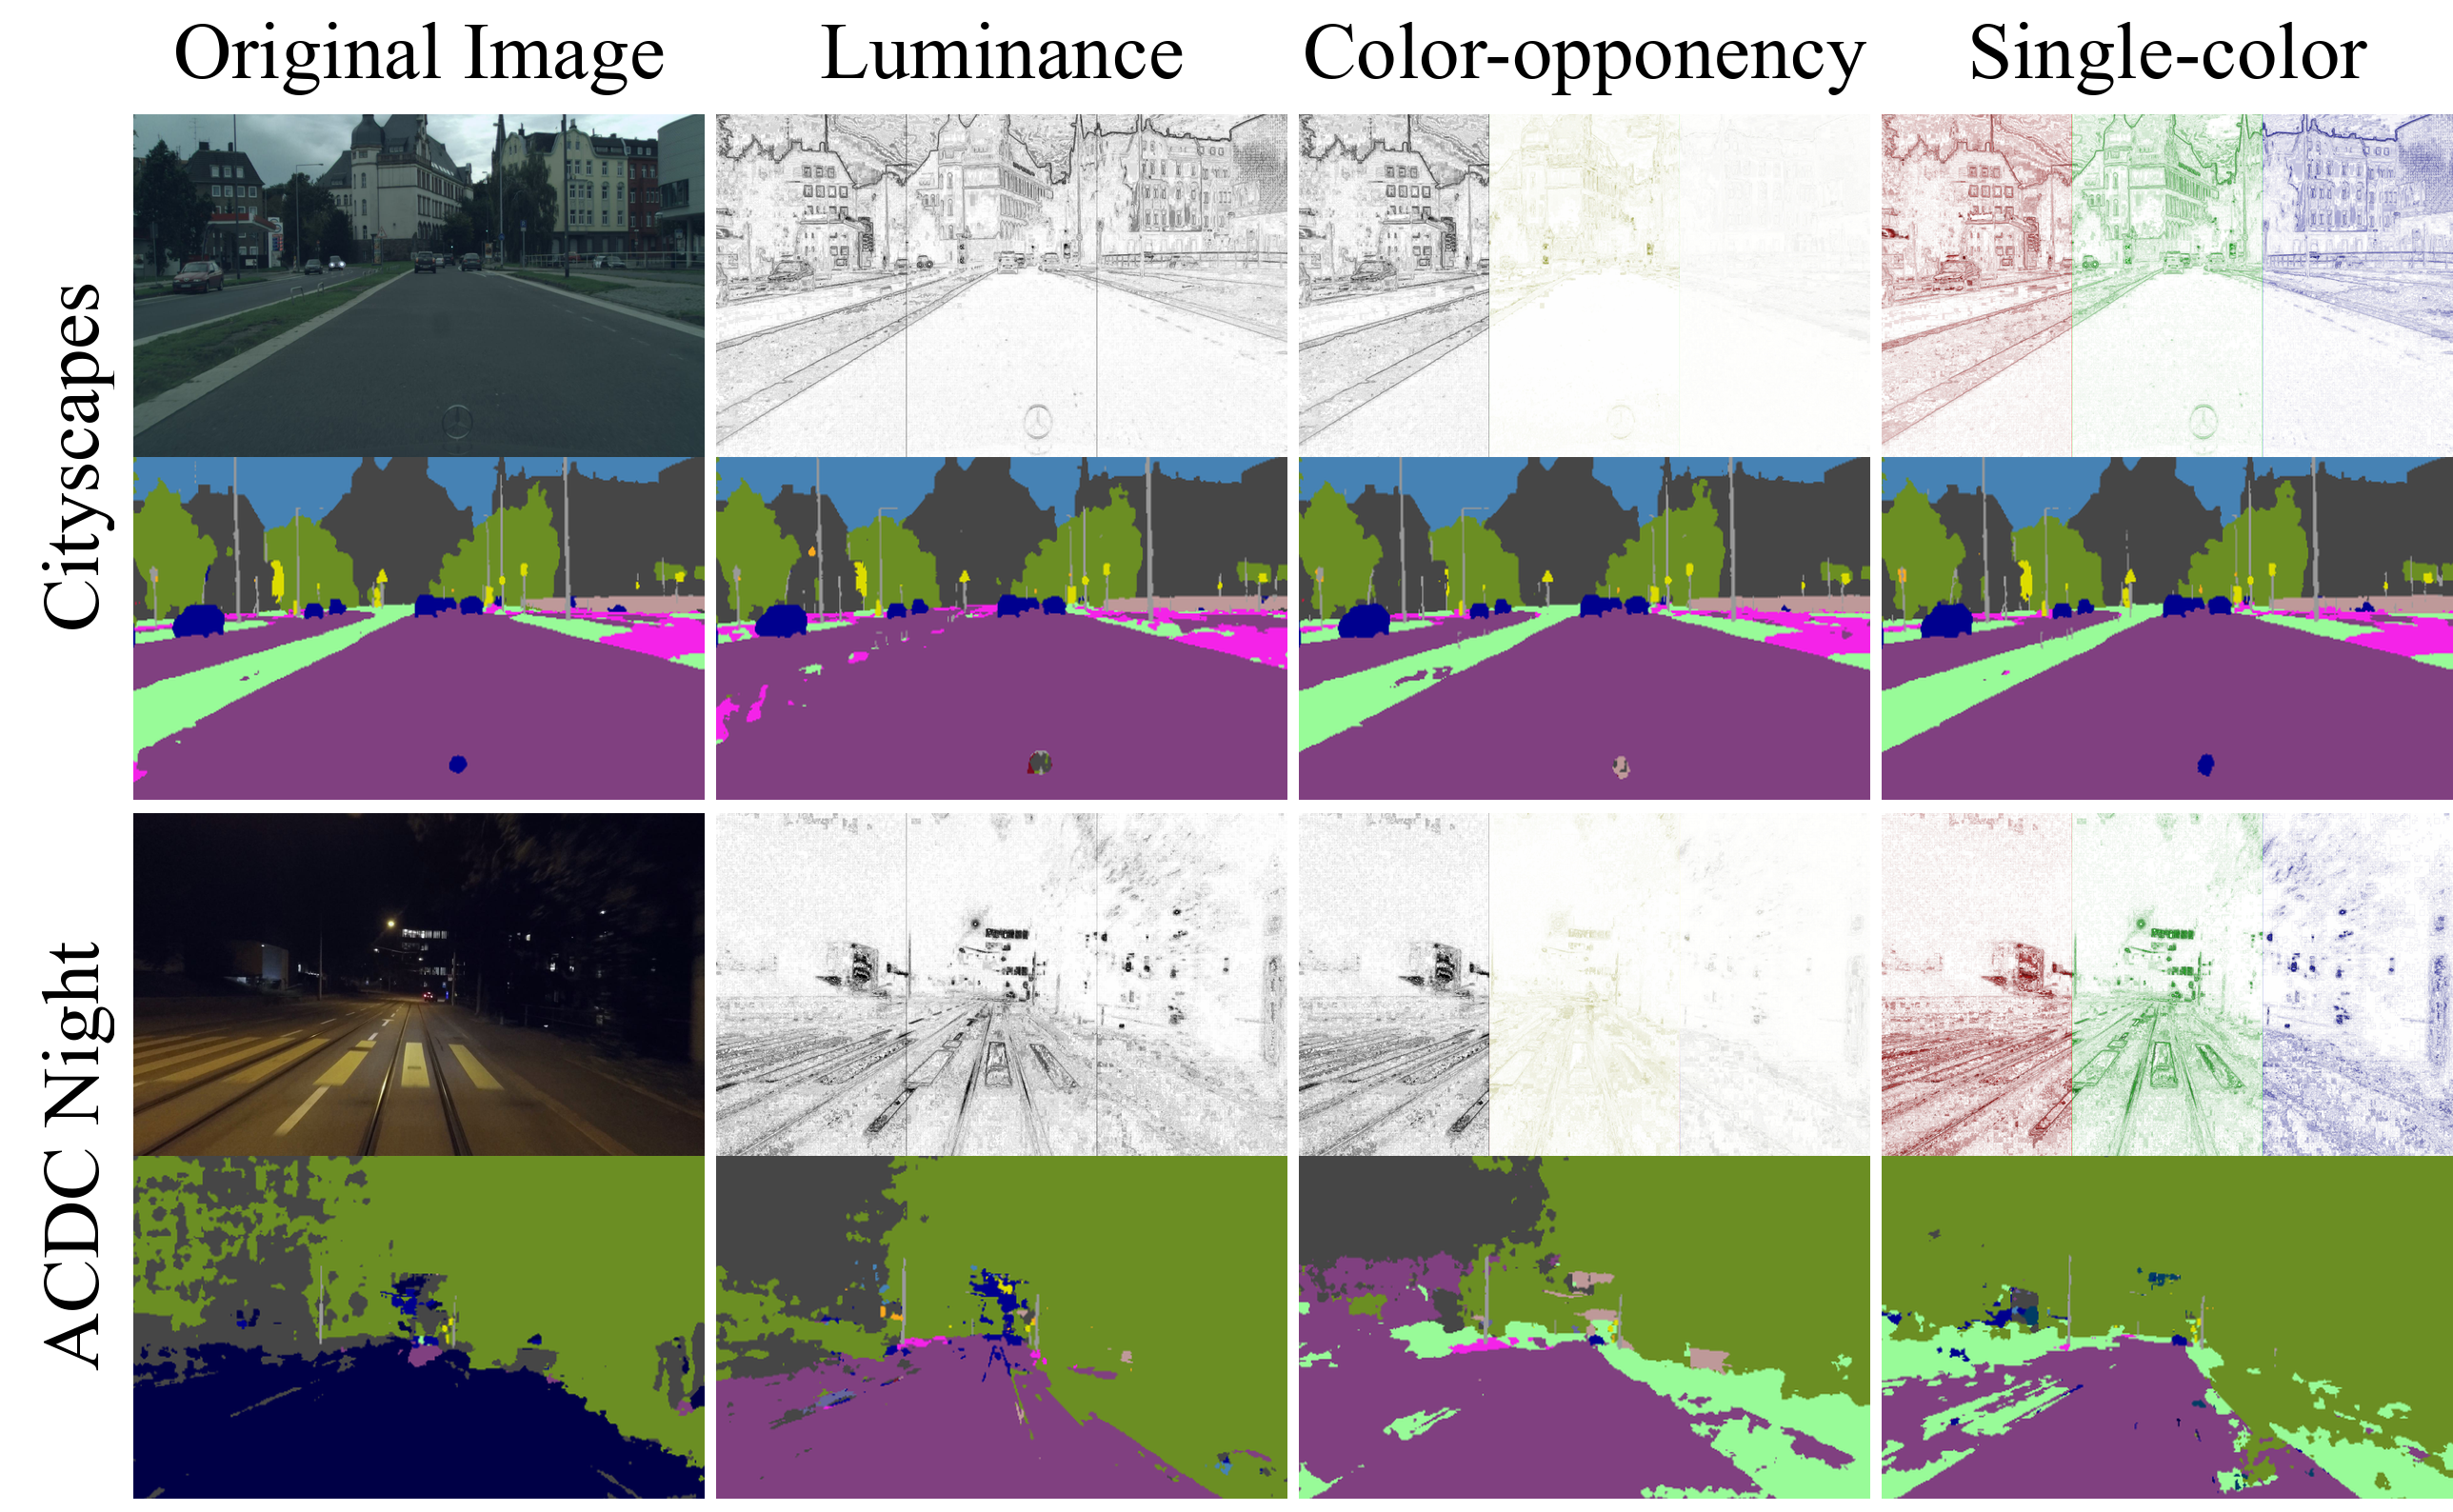

In [33]:
from PIL import Image, ImageDraw, ImageFont
import os
from pdf2image import convert_from_path

# ----------------- Einstellungen -----------------
root = "/home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing_new/ECCV_2026_Paper_Preprocessing"  
base = os.path.join(root, "figures", "teaser")
out_png = "teaser_exact_final.png"
out_pdf = "teaser_exact_final.pdf"
poppler_path = None  # optional anpassen, z.B. "/usr/bin"

# Layout-Proportionen
col_group_width = 600
slice_width = col_group_width // 3
target_h = 360
mask_h = target_h
left_label_w = 70
top_header_h = 120
col_gap = 12
row_gap = 14
bg = (255,255,255)
crop_factor = 0.03
fontsize=20

# Fonts
try:
    font_path = "/home/lstracke/Data/times.ttf"
    font_header = ImageFont.truetype(font_path, 85)
    font_label  = ImageFont.truetype(font_path, 85)
    font_small  = ImageFont.truetype(font_path, 12)
except Exception:
    font_header = ImageFont.load_default()
    font_label  = ImageFont.load_default()
    font_small  = ImageFont.load_default()

# ----------------- Hilfsfunktionen -----------------
def crop_image_mask(im, crop_factor=crop_factor):
    w,h = im.size
    l = int(w*crop_factor)
    t = int(h*crop_factor)
    r = int(w*(1-crop_factor))
    b = int(h*(1-crop_factor))
    if r-l > 5 and b-t > 5:
        im = im.crop((l,t,r,b))
    return im

def crop_image_slice(im, channel, crop_factor=crop_factor):
    w,h = im.size
    l,t,r,b = 0,0,w,h
    if channel == 'R':
        l = int(w*crop_factor)
        t = int(h*crop_factor)
        b = int(h*(1-crop_factor))
    elif channel == 'G':
        t = int(h*crop_factor)
        b = int(h*(1-crop_factor))
    elif channel == 'B':
        t = int(h*crop_factor)
        b = int(h*(1-crop_factor))
        r = int(w*(1-crop_factor))
    if r-l > 5 and b-t > 5:
        im = im.crop((l,t,r,b))
    return im

def load_any(path, dpi=150, slice_channel=None, is_orig=False):
    """Lädt PDF oder Bild, optional Cropping für Masken, Slices oder Original Images."""
    if not os.path.exists(path):
        return None
    try:
        if path.lower().endswith(".pdf"):
            pages = convert_from_path(path, dpi=dpi, poppler_path=poppler_path) if poppler_path else convert_from_path(path, dpi=dpi)
            im = pages[0].convert("RGB")
        else:
            im = Image.open(path).convert("RGB")

        if "mask" in path.lower():
            im = crop_image_mask(im)
        elif slice_channel is not None:
            im = crop_image_slice(im, slice_channel)
        elif is_orig:
            im = crop_image_mask(im)  # Crop wie Masken, alle Seiten
        return im
    except Exception as e:
        print(f"[WARN] konnte {path} nicht laden: {e}")
        return None


def make_placeholder(w,h,text="",font=font_small):
    im = Image.new("RGB",(w,h),(240,240,240))
    d = ImageDraw.Draw(im)
    bbox = d.textbbox((0,0), text, font=font)
    tw = bbox[2]-bbox[0]; th = bbox[3]-bbox[1]
    x = (w-tw)//2; y = (h-th)//2
    d.text((x,y), text, font=font, fill=(0,0,0))
    return im

def concat_horiz(images, bg=bg):
    if not images:
        return None
    total_w = sum(im.width for im in images)
    h = max(im.height for im in images)
    out = Image.new("RGB",(total_w,h),bg)
    x=0
    for im in images:
        out.paste(im,(x,(h-im.height)//2))
        x += im.width
    return out

# ----------------- Dateipfade wie im LaTeX -----------------
def p(*parts):
    return os.path.join(base, *parts)

# ... hier file_map wie bisher einfügen (unverändert, siehe dein Code) ...
file_map = {
    # Cityscapes
    ("Cityscapes", "Original Image"): [ p("image_beforeRGB.pdf") ],
    ("Cityscapes", "Grayscale"): [
        p("sliced_processed","image_beforeRGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_beforeRGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_beforeRGB-1_-3gray_sig-b.pdf"),
    ],
    ("Cityscapes", "Color-opponency"): [
        p("sliced_processed","image_beforeRGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_beforeRGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_beforeRGB-1_-3co_sig-b.pdf"),
    ],
    ("Cityscapes", "Single-color"): [
        p("sliced_processed","image_beforeRGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_beforeRGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_beforeRGB-1_-3sc_sig-b.pdf"),
    ],
    ("Cityscapes", "Masks"): [
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_baseline_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_bw_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_co_mask.pdf"),
        p("segmentation_masks_cityscapes","aachen_000001_000019_leftImg8bit_sc_mask.pdf"),
    ],

    # ACDC Night
    ("ACDC Night", "Original Image"): [ p("image_before_acdc_nightRGB.pdf") ],
    ("ACDC Night", "Grayscale"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1gray_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2gray_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3gray_sig-b.pdf"),
    ],
    ("ACDC Night", "Color-opponency"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1co_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2co_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3co_sig-b.pdf"),
    ],
    ("ACDC Night", "Single-color"): [
        p("sliced_processed","image_before_acdc_night_RGB-1_-1sc_sig-r.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-2sc_sig-g.pdf"),
        p("sliced_processed","image_before_acdc_night_RGB-1_-3sc_sig-b.pdf"),
    ],
    ("ACDC Night", "Masks"): [
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_baseline_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_bw_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_co_mask.pdf"),
        p("segmentation_masks_acdc_night","GOPR0351_frame_000039_rgb_anon_sc_mask.pdf"),
    ],
}


# ----------------- Erzeuge Zellen -----------------
# ----------------- Spalten und Reihen -----------------
columns = ["Original Image","Luminance","Color-opponency","Single-color"]  
rows = ["Cityscapes", "ACDC Night"]  

cells = {}

for row in rows:
    # Original Image
    orig_files = file_map.get((row,"Original Image"), [])
    if orig_files:
        im = load_any(orig_files[0], is_orig=True)  # <-- hier is_orig=True
        if im is None:
            im = make_placeholder(col_group_width, target_h, text=os.path.basename(orig_files[0]))
        else:
            im = im.resize((col_group_width, target_h), Image.LANCZOS)
    else:
        im = make_placeholder(col_group_width, target_h, text="(no orig)")
    cells[(row,"Original Image")] = im

    # Slices
    slice_cols = ["Luminance","Color-opponency","Single-color"]
    channels = ['R','G','B']
    for colname in slice_cols:
        files = file_map.get((row, "Grayscale" if colname=="Luminance" else colname), [])
        parts=[]
        for i in range(3):
            if i < len(files):
                f = files[i]
                p_img = load_any(f, slice_channel=channels[i])
                if p_img is None:
                    p_img = make_placeholder(slice_width, target_h, text=os.path.basename(f))
                else:
                    p_img = p_img.resize((slice_width, target_h), Image.LANCZOS)
            else:
                p_img = make_placeholder(slice_width, target_h)
            parts.append(p_img)
        grouped = concat_horiz(parts)
        cells[(row,colname)] = grouped

    # Masks
    mask_files = file_map.get((row,"Masks"), [])
    for j in range(4):
        if j < len(mask_files):
            f = mask_files[j]
            m = load_any(f)
            if m is None:
                m = make_placeholder(col_group_width, mask_h, text=os.path.basename(f))
            else:
                m = m.resize((col_group_width, mask_h), Image.LANCZOS)
        else:
            m = make_placeholder(col_group_width, mask_h, text="(no mask)")
        colkey = ["Original Image","Grayscale","Color-opponency","Single-color"][j]
        cells[(row,f"mask_{colkey}")] = m

# ----------------- Gesamt-Canvas -----------------
W = left_label_w + 4*col_group_width + 3*col_gap
H = top_header_h + sum((target_h + mask_h + row_gap) for _ in rows)
canvas = Image.new("RGB",(W,H),bg)
draw = ImageDraw.Draw(canvas)

# Header
x = left_label_w
for col in columns:
    tw = draw.textbbox((0,0), col, font=font_header)[2]
    draw.text((x + (col_group_width - tw)/2, 6), col, font=font_header, fill=(0,0,0), fontsize=fontsize)
    x += col_group_width + col_gap

left_label_w = 140  # genug Platz für lange Zeilenlabels

# Gesamt-Canvas berechnen: erst nach allen Zellenbreiten/Zeilenhöhen
W = left_label_w + 4*col_group_width + 3*col_gap
H = top_header_h + sum((target_h + mask_h + row_gap) for _ in rows)
canvas = Image.new("RGB",(W,H),bg)
draw = ImageDraw.Draw(canvas)

# ----------------- Header zentrieren -----------------
x = left_label_w
for col in columns:
    bbox = draw.textbbox((0,0), col, font=font_header)
    tw = bbox[2]-bbox[0]
    draw.text((x + (col_group_width - tw)/2, 6), col, font=font_header, fill=(0,0,0), fontsize=fontsize)
    x += col_group_width + col_gap

# ----------------- Zeilenbeschriftungen und Zellen -----------------
y = top_header_h
for row in rows:
    # Höhe der Zeile (Zellen + Masken)
    row_h = target_h + mask_h

    # --- Label direkt als Image erzeugen ---
    bbox = draw.textbbox((0,0), row, font=font_label)
    tw = bbox[2]-bbox[0]
    th = bbox[3]-bbox[1]
    pad = 6  # Puffer für Rotation
    temp = Image.new("RGBA", (tw + pad*2, th + pad*2 + 10), (0,0,0,0))
    td = ImageDraw.Draw(temp)
    td.text((pad,pad), row, font=font_label, fill=(0,0,0), fontsize=fontsize)
    temp = temp.rotate(90, expand=True)

    # Mittig innerhalb des linken Bereichs und vertikal zur Zeilenhöhe
    cx = left_label_w // 2
    cy = y + row_h // 2
    canvas.paste(temp, (cx - temp.width//2, cy - temp.height//2), temp)

    # --- Zellen einfügen ---
    x = left_label_w
    for col in columns:
        canvas.paste(cells[(row,col)], (x,y))
        x += col_group_width + col_gap

    # --- Masken einfügen ---
    y_mask = y + target_h
    x = left_label_w
    for col in columns:
        col_key = 'Grayscale' if col == 'Luminance' else col
        canvas.paste(cells[(row,f"mask_{col_key}")], (x,y_mask))
        x += col_group_width + col_gap

    y += row_h + row_gap

# ----------------- Canvas speichern -----------------
canvas.save(out_png)
canvas.save(out_pdf)
print("Speichern fertig:", out_png, out_pdf)




# Optional anzeigen
display(canvas)


In [7]:
from PIL import Image, ImageDraw, ImageFont
from pdf2image import convert_from_path
import os

# ----------------- Einstellungen -----------------
#root = "/home/lstracke/Downloads/ECCV_2026_Paper_Preprocessing"   # <-- anpassen

root = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Segmentation-masks\\"
base = root# os.path.join(root, "figures", "teaser")
out_png = "teaser_exact_cropped_fixed_long.png"
out_pdf = "teaser_exact_cropped_fixed_long.pdf"
poppler_path = None  # optional anpassen, z.B. "/usr/bin"

# Layout-Proportionen
col_group_width = 600
slice_width = col_group_width // 3
target_h = 360
mask_h = target_h
# left_label_w wird **dynamisch** bestimmt weiter unten
left_label_w = 70
top_header_h = 110
col_gap = 12
row_gap = 14
bg = (255,255,255)
crop_factor = 0.03

# Fonts
try:
    font_path = "/home/lstracke/Data/times.ttf"
    font_header = ImageFont.truetype(font_path, 80)
    font_label  = ImageFont.truetype(font_path, 80)
    font_small  = ImageFont.truetype(font_path, 12)
except Exception:
    font_header = ImageFont.load_default()
    font_label  = ImageFont.load_default()
    font_small  = ImageFont.load_default()

# ----------------- Hilfsfunktionen (wie bei dir) -----------------
def crop_image_mask(im, crop_factor=crop_factor):
    w,h = im.size
    l = int(w*crop_factor); t = int(h*crop_factor)
    r = int(w*(1-crop_factor)); b = int(h*(1-crop_factor))
    if r-l > 5 and b-t > 5:
        im = im.crop((l,t,r,b))
    return im

def crop_image_slice(im, channel, crop_factor=crop_factor):
    w,h = im.size
    l,t,r,b = 0,0,w,h
    if channel == 'R':
        l = int(w*crop_factor); t = int(h*crop_factor); b = int(h*(1-crop_factor))
    elif channel == 'G':
        t = int(h*crop_factor); b = int(h*(1-crop_factor))
    elif channel == 'B':
        t = int(h*crop_factor); b = int(h*(1-crop_factor)); r = int(w*(1-crop_factor))
    if r-l > 5 and b-t > 5:
        im = im.crop((l,t,r,b))
    return im

def load_any(path, dpi=150, slice_channel=None, is_orig=False):
    if not path or not os.path.exists(path):
        return None
    try:
        if path.lower().endswith(".pdf"):
            pages = convert_from_path(path, dpi=dpi, poppler_path=poppler_path) if poppler_path else convert_from_path(path, dpi=dpi)
            im = pages[0].convert("RGB")
        else:
            im = Image.open(path).convert("RGB")

        if "mask" in path.lower():
            im = crop_image_mask(im)
        elif slice_channel is not None:
            im = crop_image_slice(im, slice_channel)
        elif is_orig:
            im = crop_image_mask(im)
        return im
    except Exception as e:
        print(f"[WARN] konnte {path} nicht laden: {e}")
        return None
    

    

def make_placeholder(w,h,text="",font=font_small):
    im = Image.new("RGB",(w,h),(240,240,240))
    d = ImageDraw.Draw(im)
    bbox = d.textbbox((0,0), text, font=font)
    tw = bbox[2]-bbox[0]; th = bbox[3]-bbox[1]
    d.text(((w-tw)//2,(h-th)//2), text, font=font, fill=(0,0,0))
    return im

def concat_horiz(images, bg=bg):
    if not images:
        return None
    total_w = sum(im.width for im in images)
    h = max(im.height for im in images)
    out = Image.new("RGB",(total_w,h),bg)
    x=0
    for im in images:
        out.paste(im,(x,(h-im.height)//2))
        x += im.width
    return out

def p(*parts):
    return os.path.join(base, *parts)

# ----------------- file_map (wie von dir) -----------------
file_map = {
    ("Cityscapes", "Original Image"): [ p("cityscapes.png") ],
    ("Cityscapes", "Grayscale"): [
        p("sliced_processed","acdc_fog_bw_07-bw_crop1-RGB.png"),#cityscapes-teaser_bw_07-bw_crop1-RGB.png"),
        p("sliced_processed","cityscapes-teaser_bw_07-bw_crop2-RGB.png"),
        p("sliced_processed","cityscapes-teaser_bw_07-bw_crop3-RGB.png"),
    ],
    ("Cityscapes", "Color-opponency"): [
        p("sliced_processed","cityscapes-teaser_bw_07-bw_crop1-RGB.png"),
        p("sliced_processed","cityscapes-teaser_co_07-rg_crop2-RGB.png"),
        p("sliced_processed","cityscapes-teaser_co_07-bg_crop3-RGB.png"),
    ],
    ("Cityscapes", "Single-color"): [
        p("sliced_processed","cityscapes-teaser_rgb_07-r_crop1-RGB.png"),
        p("sliced_processed","cityscapes-teaser_rgb_07-g_crop2-RGB.png"),
        p("sliced_processed","cityscapes-teaser_rgb_07-b_crop3-RGB.png"),
    ],
    ("Cityscapes", "Masks"): [ 
        p("aachen_000001_000019_leftImg8bit_baseline_mask0.0.png"),
        p("aachen_000001_000019_leftImg8bit_bw_mask0.7.png"),
        p("aachen_000001_000019_leftImg8bit_co_mask0.7.png"),
        p("aachen_000001_000019_leftImg8bit_sc_mask0.7.png"),
    ],
    # Dark Zurich
    ("Dark Zurich", "Original Image"): [ p("GOPR0356_frame_000375_rgb_anon.png") ],
    ("Dark Zurich", "Grayscale"): [
        p("sliced_processed","dark-zurich-teaser_bw_07-bw_crop1-RGB.png"),
        p("sliced_processed","dark-zurich-teaser_bw_07-bw_crop2-RGB.png"),
        p("sliced_processed","dark-zurich-teaser_bw_07-bw_crop3-RGB.png"),
    ],
    ("Dark Zurich", "Color-opponency"): [
        p("sliced_processed","dark-zurich-teaser_bw_07-bw_crop1-RGB.png"),
        p("sliced_processed","dark-zurich-teaser_co_07-rg_crop2-RGB.png"),
        p("sliced_processed","dark-zurich-teaser_co_07-bg_crop3-RGB.png"),
    ],
    ("Dark Zurich", "Single-color"): [
        p("sliced_processed","dark-zurich-teaser_rgb_07-r_crop1-RGB.png"),
        p("sliced_processed","dark-zurich-teaser_rgb_07-g_crop2-RGB.png"),
        p("sliced_processed","dark-zurich-teaser_rgb_07-b_crop3-RGB.png"),
    ],
    ("Dark Zurich", "Masks"): [
        p("GOPR0356_frame_000375_rgb_anon_baseline_mask0.0.png"),
        p("GOPR0356_frame_000375_rgb_anon_bw_mask0.7.png"),
        p("GOPR0356_frame_000375_rgb_anon_co_mask0.7.png"),
        p("GOPR0356_frame_000375_rgb_anon_sc_mask0.7.png"),
    ],
    # ACDC Night
    ("ACDC Night", "Original Image"): [ p("acdc_night.png") ],
    ("ACDC Night", "Grayscale"): [
        p("sliced_processed","acdc_night_bw_07-bw_crop1-RGB.png"),
        p("sliced_processed","acdc_night_bw_07-bw_crop2-RGB.png"),
        p("sliced_processed","acdc_night_bw_07-bw_crop3-RGB.png"),
    ],
    ("ACDC Night", "Color-opponency"): [
        p("sliced_processed","acdc_night_co_07-bw_crop1-RGB.png"),
        p("sliced_processed","acdc_night_co_07-rg_crop2-RGB.png"),
        p("sliced_processed","acdc_night_co_07-bg_crop3-RGB.png"),
    ],
    ("ACDC Night", "Single-color"): [
        p("sliced_processed","acdc_night_rgb_07-r_crop1-RGB.png"),
        p("sliced_processed","acdc_night_rgb_07-g_crop2-RGB.png"),
        p("sliced_processed","acdc_night_rgb_07-b_crop3-RGB.png"),
    ],
    ("ACDC Night", "Masks"): [
        p("GOPR0351_frame_000039_rgb_anon_baseline_mask0.0.png"),
        p("GOPR0351_frame_000039_rgb_anon_bw_mask0.7.png"),
        p("GOPR0351_frame_000039_rgb_anon_co_mask0.7.png"),
        p("GOPR0351_frame_000039_rgb_anon_sc_mask0.7.png"),
    ],
    # ACDC Snow
    ("ACDC Snow", "Original Image"): [ p("acdc_snow.png") ],
    ("ACDC Snow", "Grayscale"): [
        p("sliced_processed","acdc_snow_bw_07-bw_crop1-RGB.png"),
        p("sliced_processed","acdc_snow_bw_07-bw_crop2-RGB.png"),
        p("sliced_processed","acdc_snow_bw_07-bw_crop3-RGB.png"),
    ],
    ("ACDC Snow", "Color-opponency"): [
        p("sliced_processed","acdc_snow_co_07-bw_crop1-RGB.png"),
        p("sliced_processed","acdc_snow_co_07-rg_crop2-RGB.png"),
        p("sliced_processed","acdc_snow_co_07-bg_crop3-RGB.png"),
    ],
    ("ACDC Snow", "Single-color"): [
        p("sliced_processed","acdc_snow_rgb_07-r_crop1-RGB.png"),
        p("sliced_processed","acdc_snow_rgb_07-g_crop2-RGB.png"),
        p("sliced_processed","acdc_snow_rgb_07-b_crop3-RGB.png"),
    ],
    ("ACDC Snow", "Masks"): [
        p("GOPR0122_frame_000018_rgb_anon_baseline_mask0.0.png"),
        p("GOPR0122_frame_000018_rgb_anon_bw_mask0.7.png"),
        p("GOPR0122_frame_000018_rgb_anon_co_mask0.7.png"),
        p("GOPR0122_frame_000018_rgb_anon_sc_mask0.7.png"),
    ],
    # ACDC Fog
    ("ACDC Fog", "Original Image"): [ p("acdc_fog.png") ],
    ("ACDC Fog", "Grayscale"): [
        p("sliced_processed","acdc_fog_bw_07-bw_crop1-RGB.png"),
        p("sliced_processed","acdc_fog_bw_07-bw_crop2-RGB.png"),
        p("sliced_processed","acdc_fog_bw_07-bw_crop3-RGB.png"),
    ],
    ("ACDC Fog", "Color-opponency"): [
        p("sliced_processed","acdc_fog_co_07-bw_crop1-RGB.png"),
        p("sliced_processed","acdc_fog_co_07-rg_crop2-RGB.png"),
        p("sliced_processed","acdc_fog_co_07-bg_crop3-RGB.png"),
    ],
    ("ACDC Fog", "Single-color"): [
        p("sliced_processed","acdc_fog_rgb_07-r_crop1-RGB.png"),
        p("sliced_processed","acdc_fog_rgb_07-g_crop2-RGB.png"),
        p("sliced_processed","acdc_fog_rgb_07-b_crop3-RGB.png"),
    ],
    ("ACDC Fog", "Masks"): [
        p("GOPR0476_frame_000769_rgb_anon_baseline_mask0.0.png"),
        p("GOPR0476_frame_000769_rgb_anon_bw_mask0.7.png"),
        p("GOPR0476_frame_000769_rgb_anon_co_mask0.7.png"),
        p("GOPR0476_frame_000769_rgb_anon_sc_mask0.7.png"),
    ],
    # ACDC Rain
    ("ACDC Rain", "Original Image"): [ p("acdc_rain.png") ],
    ("ACDC Rain", "Grayscale"): [
        p("sliced_processed","acdc_rain_bw_07-bw_crop1-RGB.png"),
        p("sliced_processed","acdc_rain_bw_07-bw_crop2-RGB.png"),
        p("sliced_processed","acdc_rain_bw_07-bw_crop3-RGB.png"),
    ],
    ("ACDC Rain", "Color-opponency"): [
        p("sliced_processed","acdc_rain_co_07-bw_crop1-RGB.png"),
        p("sliced_processed","acdc_rain_co_07-rg_crop2-RGB.png"),
        p("sliced_processed","acdc_rain_co_07-bg_crop3-RGB.png"),
    ],
    ("ACDC Rain", "Single-color"): [
        p("sliced_processed","acdc_rain_rgb_07-r_crop1-RGB.png"),
        p("sliced_processed","acdc_rain_rgb_07-g_crop2-RGB.png"),
        p("sliced_processed","acdc_rain_rgb_07-b_crop3-RGB.png"),
    ],
    ("ACDC Rain", "Masks"): [
        p("GOPR0400_frame_000087_rgb_anon_baseline_mask0.0.png"),
        p("GOPR0400_frame_000087_rgb_anon_bw_mask0.7.png"),
        p("GOPR0400_frame_000087_rgb_anon_co_mask0.7.png"),
        p("GOPR0400_frame_000087_rgb_anon_sc_mask0.7.png"),
    ],
}

# ----------------- Spalten & Reihen -----------------
columns = ["Original Image","Luminance","Color-opponency","Single-color"]
rows = ["Cityscapes","Dark Zurich","ACDC Night","ACDC Fog","ACDC Rain","ACDC Snow"]

# ----------------- Vorbereiten: Zellen laden -----------------
cells = {}
for row in rows:
    # Orig
    orig_files = file_map.get((row,"Original Image"), [])
    if orig_files:
        im = load_any(orig_files[0], is_orig=True)
        if im is None:
            im = make_placeholder(col_group_width, target_h, text=os.path.basename(orig_files[0]))
        else:
            im = im.resize((col_group_width, target_h), Image.LANCZOS)
    else:
        im = make_placeholder(col_group_width, target_h, text="(no orig)")
    cells[(row,"Original Image")] = im

    # Slices (Luminance maps to Grayscale files)
    slice_cols = ["Luminance","Color-opponency","Single-color"]
    channels = ['R','G','B']
    for colname in slice_cols:
        files = file_map.get((row, "Grayscale" if colname=="Luminance" else colname), [])
        parts=[]
        for i in range(3):
            if i < len(files):
                f = files[i]
                p_img = load_any(f, slice_channel=channels[i])
                if p_img is None:
                    p_img = make_placeholder(slice_width, target_h, text=os.path.basename(f))
                else:
                    p_img = p_img.resize((slice_width, target_h), Image.LANCZOS)
            else:
                p_img = make_placeholder(slice_width, target_h)
            parts.append(p_img)
        grouped = concat_horiz(parts)
        cells[(row,colname)] = grouped

    # Masks
    mask_files = file_map.get((row,"Masks"), [])
    for j in range(4):
        if j < len(mask_files):
            f = mask_files[j]
            m = load_any(f)
            if m is None:
                m = make_placeholder(col_group_width, mask_h, text=os.path.basename(f))
            else:
                m = m.resize((col_group_width, mask_h), Image.LANCZOS)
        else:
            m = make_placeholder(col_group_width, mask_h, text="(no mask)")
        colkey = ["Original Image","Grayscale","Color-opponency","Single-color"][j]
        cells[(row,f"mask_{colkey}")] = m

# ----------------- WICHTIG: Erzeuge rotierte Label-Images VOR Canvas und max Breite messen ----
rotated_labels = {}
max_label_width = 0
pad = 50
# We need a Draw object temporarily to compute textbbox; create a small temp image
tmp_canvas = Image.new("RGB",(10,10),bg)
tmp_draw = ImageDraw.Draw(tmp_canvas)

for row in rows:
    bbox = tmp_draw.textbbox((0,0), row, font=font_label)
    tw = bbox[2]-bbox[0]; th = bbox[3]-bbox[1]
    temp = Image.new("RGBA", (tw + pad*2, th + pad*2), (0,0,0,0))
    td = ImageDraw.Draw(temp)
    td.text((pad,pad), row, font=font_label, fill=(0,0,0))
    temp = temp.rotate(90, expand=True)
    rotated_labels[row] = temp

    row_h = max(target_h + mask_h, temp.height + 30) 
    
    if temp.width > max_label_width:
        max_label_width = temp.width

# add small margin
left_label_w = max_label_width + 20

# ----------------- Gesamt-Canvas Größe -----------------
W = left_label_w + 4*col_group_width + 3*col_gap
H = top_header_h + sum((target_h + mask_h + row_gap) for _ in rows)
canvas = Image.new("RGB",(W,H),bg)
draw = ImageDraw.Draw(canvas)

# Header zentrieren
x = left_label_w
for col in columns:
    tw = draw.textbbox((0,0), col, font=font_header)[2]
    draw.text((x + (col_group_width - tw)/2, 6), col, font=font_header, fill=(0,0,0))
    x += col_group_width + col_gap

# ----------------- Rows einfügen -----------------
y = top_header_h
for row in rows:
    temp = rotated_labels[row]
    row_h = max(target_h + mask_h, temp.height + 30) 

    # Label: benutze vor-rotierte Bild und zentriere innerhalb left_label_w
    temp = rotated_labels[row]
    paste_x = (left_label_w - temp.width) // 2
    paste_y = y + (row_h - temp.height) // 2
    # safety clamp
    paste_x = max(0, paste_x)
    paste_y = max(0, paste_y)
    canvas.paste(temp, (paste_x, paste_y), temp)

    # Zellen
    x = left_label_w
    for col in columns:
        canvas.paste(cells[(row,col)], (x,y))
        x += col_group_width + col_gap

    # Masken
    y_mask = y + target_h
    x = left_label_w
    for col in columns:
        col_key = 'Grayscale' if col == 'Luminance' else col
        canvas.paste(cells[(row,f"mask_{col_key}")], (x,y_mask))
        x += col_group_width + col_gap

    y += row_h + row_gap

# ----------------- Speichern -----------------
canvas.save(out_png)
canvas.save(out_pdf)
print("Speichern fertig:", out_png, out_pdf)



Speichern fertig: teaser_exact_cropped_fixed_long.png teaser_exact_cropped_fixed_long.pdf


### new teaser

In [6]:
from PIL import Image, ImageDraw, ImageFont
from pdf2image import convert_from_path
import os

# ----------------- Einstellungen -----------------
root = "C:\\Users\\dekav\\VSC-Code\\Visualization-Notebooks\\Segmentation-masks\\"
#root = "../Segmentation-masks/"   # <-- anpassen
base = root #.path.join(root, "figures", "teaser")
out_png = "teaser_exact_cropped_fixed.png"
out_pdf = "teaser_exact_cropped_fixed.pdf"
poppler_path = None  # optional anpassen, z.B. "/usr/bin"

# Layout-Proportionen
col_group_width = 600
slice_width = col_group_width // 3
target_h = 360
mask_h = target_h
# left_label_w wird **dynamisch** bestimmt weiter unten
left_label_w = 70
top_header_h = 60
col_gap = 12
row_gap = 14
bg = (255,255,255)
crop_factor = 0.03

# Fonts
try:
    font_path = "/home/lstracke/Data/times.ttf"
    font_header = ImageFont.truetype(font_path, 50)
    font_label  = ImageFont.truetype(font_path, 50)
    font_small  = ImageFont.truetype(font_path, 12)
except Exception:
    font_header = ImageFont.load_default()
    font_label  = ImageFont.load_default()
    font_small  = ImageFont.load_default()

# ----------------- Hilfsfunktionen (wie bei dir) -----------------
def crop_image_mask(im, crop_factor=crop_factor):
    w,h = im.size
    l = int(w*crop_factor); t = int(h*crop_factor)
    r = int(w*(1-crop_factor)); b = int(h*(1-crop_factor))
    if r-l > 5 and b-t > 5:
        im = im.crop((l,t,r,b))
    return im

def crop_image_slice(im, channel, crop_factor=crop_factor):
    w,h = im.size
    l,t,r,b = 0,0,w,h
    if channel == 'R':
        l = int(w*crop_factor); t = int(h*crop_factor); b = int(h*(1-crop_factor))
    elif channel == 'G':
        t = int(h*crop_factor); b = int(h*(1-crop_factor))
    elif channel == 'B':
        t = int(h*crop_factor); b = int(h*(1-crop_factor)); r = int(w*(1-crop_factor))
    if r-l > 5 and b-t > 5:
        im = im.crop((l,t,r,b))
    return im

def load_any(path, dpi=150, slice_channel=None, is_orig=False):
    if not path or not os.path.exists(path):
        return None
    try:
        if path.lower().endswith(".pdf"):
            pages = convert_from_path(path, dpi=dpi, poppler_path=poppler_path) if poppler_path else convert_from_path(path, dpi=dpi)
            im = pages[0].convert("RGB")
        else:
            im = Image.open(path).convert("RGB")

        if "mask" in path.lower():
            im = crop_image_mask(im)
        elif slice_channel is not None:
            im = crop_image_slice(im, slice_channel)
        elif is_orig:
            im = crop_image_mask(im)
        return im
    except Exception as e:
        print(f"[WARN] konnte {path} nicht laden: {e}")
        return None

def make_placeholder(w,h,text="",font=font_small):
    im = Image.new("RGB",(w,h),(240,240,240))
    d = ImageDraw.Draw(im)
    bbox = d.textbbox((0,0), text, font=font)
    tw = bbox[2]-bbox[0]; th = bbox[3]-bbox[1]
    d.text(((w-tw)//2,(h-th)//2), text, font=font, fill=(0,0,0))
    return im

def concat_horiz(images, bg=bg):
    if not images:
        return None
    total_w = sum(im.width for im in images)
    h = max(im.height for im in images)
    out = Image.new("RGB",(total_w,h),bg)
    x=0
    for im in images:
        out.paste(im,(x,(h-im.height)//2))
        x += im.width
    return out

def p(*parts):
    return os.path.join(base, *parts)

# ----------------- file_map (wie von dir) -----------------
file_map = {
    ("Cityscapes", "Original Image"): [ p("aachen_000001_000019_leftImg8bit.png") ],
    ("Cityscapes", "Grayscale"): [
        p("cityscapes-teaser_bw_07-bw_crop1-RGB.png"),
        p("cityscapes-teaser_bw_07-bw_crop2-RGB.png"),
        p("cityscapes-teaser_bw_07-bw_crop3-RGB.png"),
    ],
    ("Cityscapes", "Color-opponency"): [
        p("cityscapes-teaser_bw_07-bw_crop1-RGB.png"),
        p("cityscapes-teaser_co_07-rg_crop2-RGB.png"),
        p("cityscapes-teaser_co_07-bg_crop3-RGB.png"),
    ],
    ("Cityscapes", "Single-color"): [
        p("cityscapes-teaser_rgb_07-r_crop1-RGB.png"),
        p("cityscapes-teaser_rgb_07-g_crop2-RGB.png"),
        p("cityscapes-teaser_rgb_07-b_crop3-RGB.png"),
    ],
    ("Cityscapes", "Masks"): [ 
        p("aachen_000001_000019_leftImg8bit_baseline_mask0.0.png"),
        p("aachen_000001_000019_leftImg8bit_bw_mask0.7.png"),
        p("aachen_000001_000019_leftImg8bit_co_mask0.7.png"),
        p("aachen_000001_000019_leftImg8bit_sc_mask0.7.png"),
    ],
    # Dark Zurich
    ("Dark Zurich", "Original Image"): [ p("GOPR0356_frame_000375_rgb_anon.png") ],
    ("Dark Zurich", "Grayscale"): [
        p("dark-zurich-teaser_bw_07-bw_crop1-RGB.png"),
        p("dark-zurich-teaser_bw_07-bw_crop2-RGB.png"),
        p("dark-zurich-teaser_bw_07-bw_crop3-RGB.png"),
    ],
    ("Dark Zurich", "Color-opponency"): [
        p("dark-zurich-teaser_bw_07-bw_crop1-RGB.png"),
        p("dark-zurich-teaser_co_07-rg_crop2-RGB.png"),
        p("dark-zurich-teaser_co_07-bg_crop3-RGB.png"),
    ],
    ("Dark Zurich", "Single-color"): [
        p("dark-zurich-teaser_rgb_07-r_crop1-RGB.png"),
        p("dark-zurich-teaser_rgb_07-g_crop2-RGB.png"),
        p("dark-zurich-teaser_rgb_07-b_crop3-RGB.png"),
    ],
    ("Dark Zurich", "Masks"): [
        p("GOPR0356_frame_000375_rgb_anon_baseline_mask0.0.png"),
        p("GOPR0356_frame_000375_rgb_anon_bw_mask0.7.png"),
        p("GOPR0356_frame_000375_rgb_anon_co_mask0.7.png"),
        p("GOPR0356_frame_000375_rgb_anon_sc_mask0.7.png"),
    ]
}

# ----------------- Spalten & Reihen -----------------
columns = ["Original Image","Luminance","Color-opponency","Single-color"]
rows = ["Cityscapes","Dark Zurich"]

# ----------------- Vorbereiten: Zellen laden -----------------
cells = {}
for row in rows:
    # Orig
    orig_files = file_map.get((row,"Original Image"), [])
    if orig_files:
        im = load_any(orig_files[0], is_orig=True)
        if im is None:
            im = make_placeholder(col_group_width, target_h, text=os.path.basename(orig_files[0]))
        else:
            im = im.resize((col_group_width, target_h), Image.LANCZOS)
    else:
        im = make_placeholder(col_group_width, target_h, text="(no orig)")
    cells[(row,"Original Image")] = im

    # Slices (Luminance maps to Grayscale files)
    slice_cols = ["Luminance","Color-opponency","Single-color"]
    channels = ['R','G','B']
    for colname in slice_cols:
        files = file_map.get((row, "Grayscale" if colname=="Luminance" else colname), [])
        parts=[]
        for i in range(3):
            if i < len(files):
                f = files[i]
                p_img = load_any(f, slice_channel=channels[i])
                if p_img is None:
                    p_img = make_placeholder(slice_width, target_h, text=os.path.basename(f))
                else:
                    p_img = p_img.resize((slice_width, target_h), Image.LANCZOS)
            else:
                p_img = make_placeholder(slice_width, target_h)
            parts.append(p_img)
        grouped = concat_horiz(parts)
        cells[(row,colname)] = grouped

    # Masks
    mask_files = file_map.get((row,"Masks"), [])
    for j in range(4):
        if j < len(mask_files):
            f = mask_files[j]
            m = load_any(f)
            if m is None:
                m = make_placeholder(col_group_width, mask_h, text=os.path.basename(f))
            else:
                m = m.resize((col_group_width, mask_h), Image.LANCZOS)
        else:
            m = make_placeholder(col_group_width, mask_h, text="(no mask)")
        colkey = ["Original Image","Grayscale","Color-opponency","Single-color"][j]
        cells[(row,f"mask_{colkey}")] = m

# ----------------- WICHTIG: Erzeuge rotierte Label-Images VOR Canvas und max Breite messen ----
rotated_labels = {}
max_label_width = 0
pad = 30
# We need a Draw object temporarily to compute textbbox; create a small temp image
tmp_canvas = Image.new("RGB",(10,10),bg)
tmp_draw = ImageDraw.Draw(tmp_canvas)

for row in rows:
    bbox = tmp_draw.textbbox((0,0), row, font=font_label)
    tw = bbox[2]-bbox[0]; th = bbox[3]-bbox[1]
    temp = Image.new("RGBA", (tw + pad*2, th + pad*2), (0,0,0,0))
    td = ImageDraw.Draw(temp)
    td.text((pad,pad), row, font=font_label, fill=(0,0,0))
    temp = temp.rotate(90, expand=True)
    rotated_labels[row] = temp
    if temp.width > max_label_width:
        max_label_width = temp.width

# add small margin
left_label_w = max_label_width + 20

# ----------------- Gesamt-Canvas Größe -----------------
W = left_label_w + 4*col_group_width + 3*col_gap
H = top_header_h + sum((target_h + mask_h + row_gap) for _ in rows)
canvas = Image.new("RGB",(W,H),bg)
draw = ImageDraw.Draw(canvas)

# Header zentrieren
x = left_label_w
for col in columns:
    tw = draw.textbbox((0,0), col, font=font_header)[2]
    draw.text((x + (col_group_width - tw)/2, 6), col, font=font_header, fill=(0,0,0))
    x += col_group_width + col_gap

# ----------------- Rows einfügen -----------------
y = top_header_h
for row in rows:
    row_h = target_h + mask_h

    # Label: benutze vor-rotierte Bild und zentriere innerhalb left_label_w
    temp = rotated_labels[row]
    paste_x = (left_label_w - temp.width) // 2
    paste_y = y + (row_h - temp.height) // 2
    # safety clamp
    paste_x = max(0, paste_x)
    paste_y = max(0, paste_y)
    canvas.paste(temp, (paste_x, paste_y), temp)

    # Zellen
    x = left_label_w
    for col in columns:
        canvas.paste(cells[(row,col)], (x,y))
        x += col_group_width + col_gap

    # Masken
    y_mask = y + target_h
    x = left_label_w
    for col in columns:
        col_key = 'Grayscale' if col == 'Luminance' else col
        canvas.paste(cells[(row,f"mask_{col_key}")], (x,y_mask))
        x += col_group_width + col_gap

    y += row_h + row_gap

# ----------------- Speichern -----------------
canvas.save(out_png)
canvas.save(out_pdf)
print("Speichern fertig:", out_png, out_pdf)



Speichern fertig: teaser_exact_cropped_fixed.png teaser_exact_cropped_fixed.pdf
